In [30]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import ipywidgets as widgets
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# path progetto
project_root = Path.cwd().resolve().parents[0]
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

print(f"Project root: {project_root}")
print(sys.path)

from prepare_inputs import prepare_matrix_inputs

Project root: /Users/marcotamburi/projects/uni_project/svd_matrix_project
['/Users/marcotamburi/.pyenv/versions/3.11.7/lib/python311.zip', '/Users/marcotamburi/.pyenv/versions/3.11.7/lib/python3.11', '/Users/marcotamburi/.pyenv/versions/3.11.7/lib/python3.11/lib-dynload', '', '/Users/marcotamburi/projects/uni_project/.venv/lib/python3.11/site-packages', '/Users/marcotamburi/projects/uni_project/src', '/Users/marcotamburi/projects/uni_project/svd_matrix_project/src']


In [31]:
data_dir = project_root / "data"

input_matrix_path = data_dir / "user_spectral_matrix.csv"
validated_matrix_path = data_dir / "validated_spectral_matrix.csv"
clean_svd_input_path = data_dir / "dati_puliti.csv"

result = prepare_matrix_inputs(
    matrix_path=input_matrix_path,
    validated_matrix_output_path=validated_matrix_path,
    clean_output_path=clean_svd_input_path,
)

matrix_df = result["matrix_df"]
clean_df = result["clean_df"]

display(matrix_df.head())
display(clean_df.head())

,Wavelength,19.0,22.0,24.0,26.0,28.0,30.0,32.0,34.0,36.0,...,82.0,84.0,86.0,88.0,90.0,92.0,94.0,96.0,98.0,100.0
0,220.0,9.14545,8.91482,9.07173,9.01981,8.68682,8.73832,8.30820,8.37373,8.61099,...,3.96002,4.08946,4.16033,3.97128,3.88501,3.73331,3.53886,3.76814,3.84650,3.41260
1,220.5,8.68515,8.40885,8.47529,8.49773,8.11777,8.24453,7.86034,7.89551,8.09573,...,3.83528,3.90419,3.95868,3.77456,3.72671,3.63317,3.46821,3.63365,3.50821,3.16371
2,221.0,8.10492,7.90851,7.91375,7.94330,7.62664,7.72780,7.38300,7.37360,7.58069,...,3.63056,3.69750,3.69167,3.57716,3.54242,3.47109,3.22223,3.37364,3.26306,2.98910
3,221.5,7.55553,7.35652,7.33385,7.36392,7.11816,7.23809,6.88920,6.81747,7.09309,...,3.42828,3.51650,3.43745,3.31281,3.29802,3.17656,3.03979,3.28692,3.03608,2.86214
4,222.0,7.06809,6.82692,6.71536,6.78927,6.55367,6.79594,6.41879,6.30302,6.54612,...,3.27368,3.24266,3.19838,3.20312,3.06177,2.96155,2.86574,3.03031,2.76850,2.73126


,19.0,22.0,24.0,26.0,28.0,30.0,32.0,34.0,36.0,38.0,...,82.0,84.0,86.0,88.0,90.0,92.0,94.0,96.0,98.0,100.0
0,9.14545,8.91482,9.07173,9.01981,8.68682,8.73832,8.30820,8.37373,8.61099,8.34158,...,3.96002,4.08946,4.16033,3.97128,3.88501,3.73331,3.53886,3.76814,3.84650,3.41260
1,8.68515,8.40885,8.47529,8.49773,8.11777,8.24453,7.86034,7.89551,8.09573,7.79673,...,3.83528,3.90419,3.95868,3.77456,3.72671,3.63317,3.46821,3.63365,3.50821,3.16371
2,8.10492,7.90851,7.91375,7.94330,7.62664,7.72780,7.38300,7.37360,7.58069,7.30087,...,3.63056,3.69750,3.69167,3.57716,3.54242,3.47109,3.22223,3.37364,3.26306,2.98910
3,7.55553,7.35652,7.33385,7.36392,7.11816,7.23809,6.88920,6.81747,7.09309,6.76435,...,3.42828,3.51650,3.43745,3.31281,3.29802,3.17656,3.03979,3.28692,3.03608,2.86214
4,7.06809,6.82692,6.71536,6.78927,6.55367,6.79594,6.41879,6.30302,6.54612,6.21240,...,3.27368,3.24266,3.19838,3.20312,3.06177,2.96155,2.86574,3.03031,2.76850,2.73126


In [32]:
wavelengths = matrix_df["Wavelength"].to_numpy(dtype=float)
T = np.array([float(col) for col in matrix_df.columns[1:]], dtype=float)

spectral_matrix = matrix_df.iloc[:, 1:].to_numpy(dtype=float)

print("spectral_matrix shape:", spectral_matrix.shape)
print("n_wavelengths:", len(wavelengths))
print("n_temperatures:", len(T))
print("Temperatures:", T)

spectral_matrix shape: (221, 41)
n_wavelengths: 221
n_temperatures: 41
Temperatures: [ 19.  22.  24.  26.  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.
  48.  50.  52.  54.  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.
  76.  78.  80.  82.  84.  86.  88.  90.  92.  94.  96.  98. 100.]


In [33]:
dft_plot = pd.read_csv(project_root / "data" / "user_spectral_matrix.csv", header=None, sep=",")
dft_plot = dft_plot.replace(",", ".", regex=True)
dft_plot = dft_plot.apply(pd.to_numeric, errors="coerce")

wl = dft_plot.iloc[1:, 0].values
T_celsius = dft_plot.iloc[0, 1:].values.astype(float)

const = (40e-6) * 32980 * 0.1
spectra = dft_plot.iloc[1:, 1:].copy() / const
spectra.columns = T_celsius
spectra.index = wl

print("Wavelengths shape:", wl.shape)
print("Temperature shape:", T_celsius.shape)
print("Spectra shape:", spectra.shape)

Wavelengths shape: (221,)
Temperature shape: (41,)
Spectra shape: (221, 41)


/var/folders/0r/bx5h09pd2p18_5m15hv_vct80000gn/T/ipykernel_3864/2152578592.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


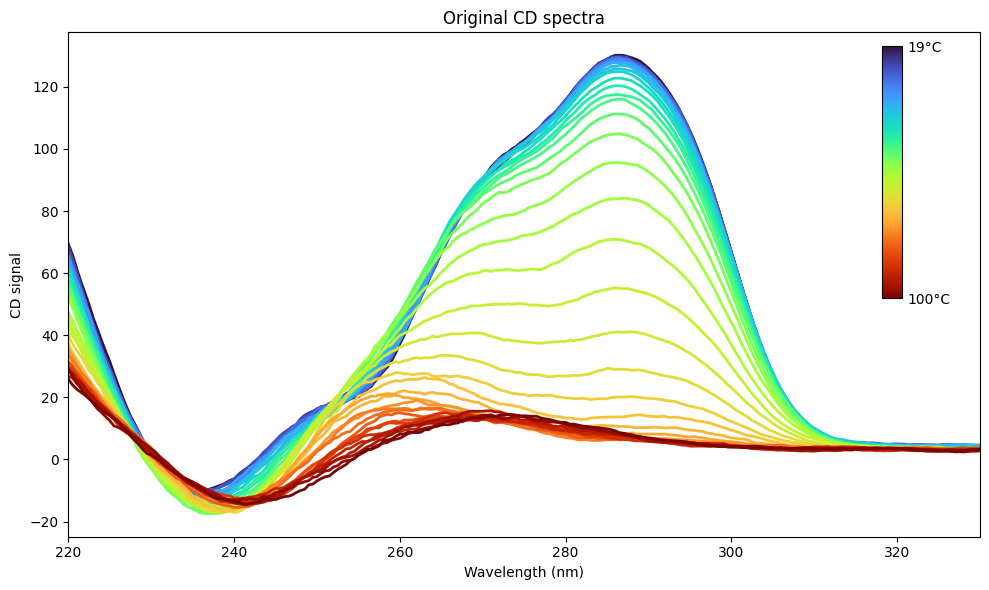

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
spectra.plot(ax=ax, cmap="turbo", linewidth=2, legend=False)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("CD signal")
ax.set_title("Original CD spectra")
ax.set_xlim(wl.min(), wl.max())

sm = plt.cm.ScalarMappable(cmap="turbo")
sm.set_array([])

cax = inset_axes(
    ax,
    width="2.2%",
    height="50%",
    loc="upper right",
    bbox_to_anchor=(-0.07, 0, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=1
)

cbar = fig.colorbar(sm, cax=cax)
cbar.set_ticks([0, 1])
cbar.set_ticklabels([f"{T_celsius.min():.0f}°C", f"{T_celsius.max():.0f}°C"])
cbar.ax.tick_params(labelsize=10, length=0)
cbar.ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [35]:
D = clean_df.astype(float).values

U, S, VT = np.linalg.svd(D, full_matrices=False)

print("D shape:", D.shape)
print("U shape:", U.shape)
print("S shape:", S.shape)
print("VT shape:", VT.shape)

D shape: (221, 41)
U shape: (221, 41)
S shape: (41,)
VT shape: (41, 41)


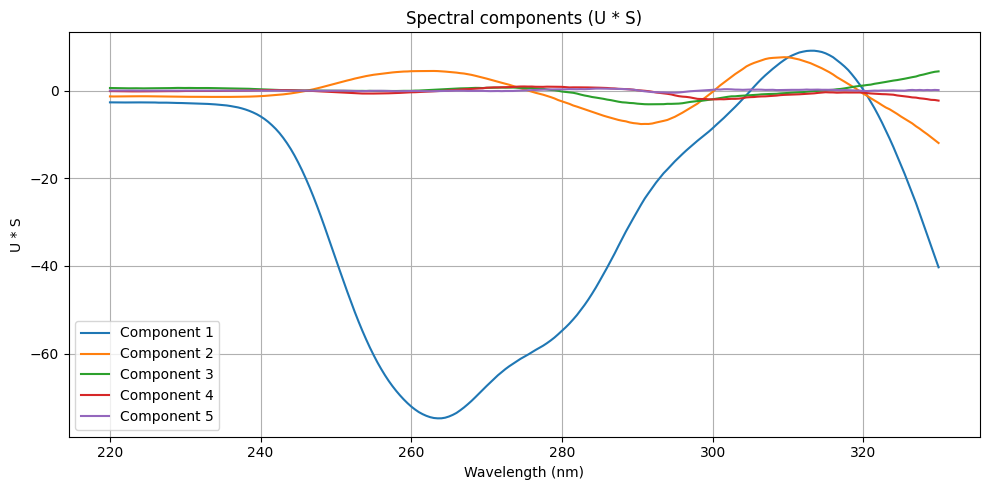

In [36]:
n_plot = min(5, U.shape[1])

plt.figure(figsize=(10, 5))
for i in range(n_plot):
    plt.plot(wl, U[:, i] * S[i], label=f"Component {i+1}")
plt.xlabel("Wavelength (nm)")
plt.ylabel("U * S")
plt.title("Spectral components (U * S)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

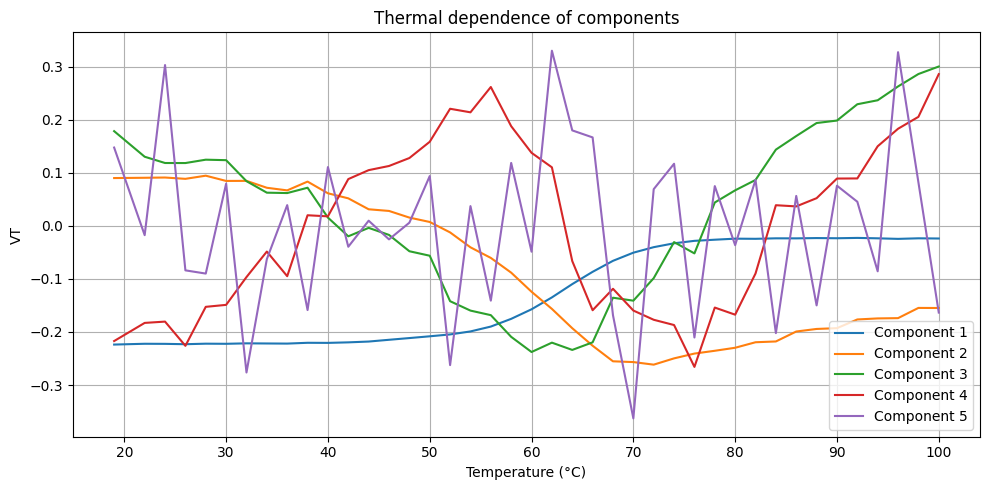

In [37]:
plt.figure(figsize=(10, 5))
for i in range(n_plot):
    plt.plot(T_celsius, VT[i, :], label=f"Component {i+1}")
plt.xlabel("Temperature (°C)")
plt.ylabel("VT")
plt.title("Thermal dependence of components")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

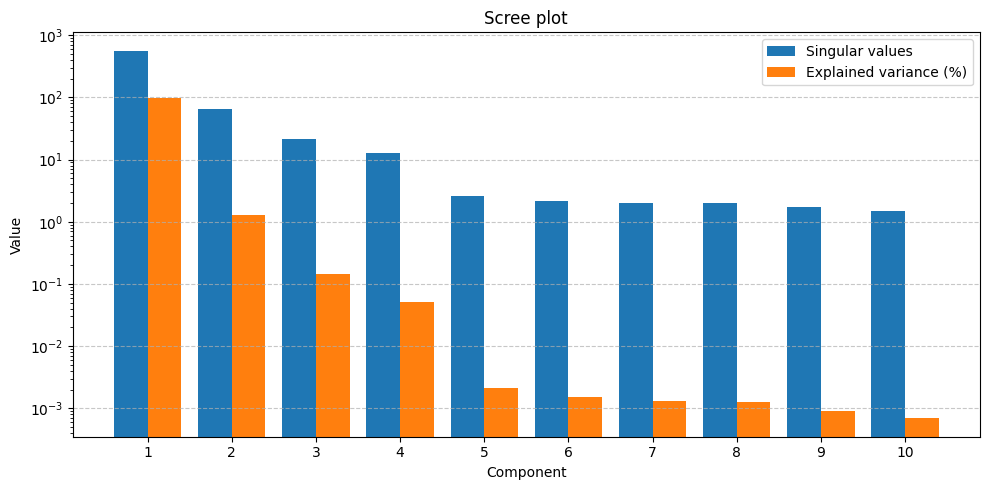

In [38]:
n_samples = D.shape[0]
explained_variance = (S**2) / (n_samples - 1)
explained_variance_ratio = explained_variance / explained_variance.sum() * 100

n_scree = min(10, len(S))
components = np.arange(1, n_scree + 1)

fig, ax = plt.subplots(figsize=(10, 5))
width = 0.4

ax.bar(components - width/2, S[:n_scree], width=width, label="Singular values")
ax.bar(components + width/2, explained_variance_ratio[:n_scree], width=width, label="Explained variance (%)")

ax.set_yscale("log")
ax.set_xlabel("Component")
ax.set_ylabel("Value")
ax.set_title("Scree plot")
ax.set_xticks(components)
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

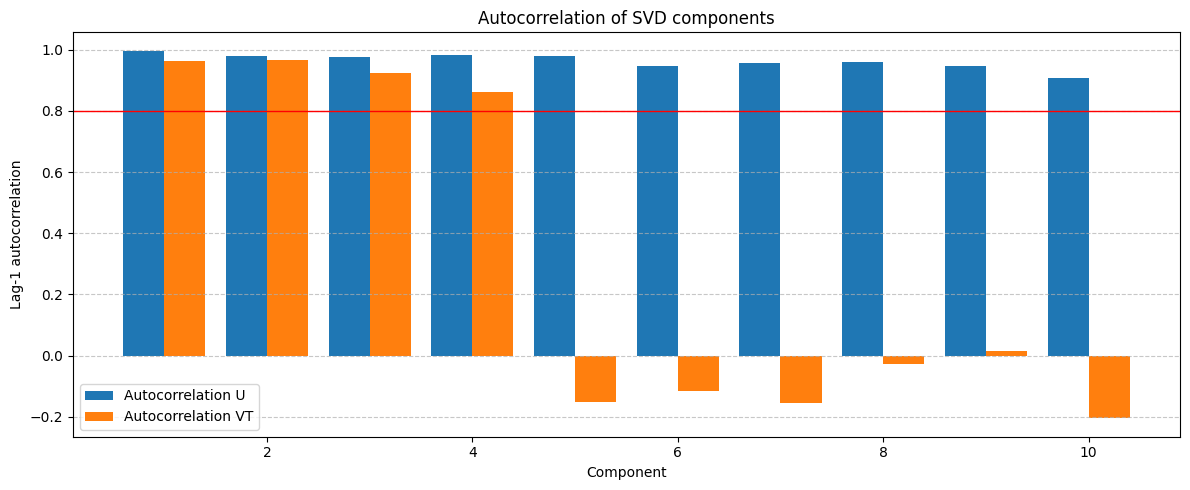

In [39]:
def autocorrelation_lag1_manual(x):
    x = x - np.mean(x)
    num = np.sum(x[:-1] * x[1:])
    den = np.sum(x ** 2)
    return num / den

autocorr_values_U = [autocorrelation_lag1_manual(U[:, i]) for i in range(U.shape[1])]
autocorr_values_VT = [autocorrelation_lag1_manual(VT[i, :]) for i in range(VT.shape[0])]

n_auto = min(10, len(autocorr_values_U))
comp = np.arange(1, n_auto + 1)

fig, ax = plt.subplots(figsize=(12, 5))
width = 0.4

ax.bar(comp - width/2, autocorr_values_U[:n_auto], width=width, label="Autocorrelation U")
ax.bar(comp + width/2, autocorr_values_VT[:n_auto], width=width, label="Autocorrelation VT")

ax.axhline(0.8, color="red", linestyle="-", linewidth=1)
ax.set_xlabel("Component")
ax.set_ylabel("Lag-1 autocorrelation")
ax.set_title("Autocorrelation of SVD components")
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

In [40]:
component_selector = widgets.Dropdown(
    options=[2, 3, 4],
    value=4,
    description="n_comp:",
)

display(component_selector)

Dropdown(description='n_comp:', index=2, options=(2, 3, 4), value=4)

In [41]:
k = int(component_selector.value)

U_k = U[:, :k]
S_k = S[:k]
VT_k = VT[:k, :]

U_prime = U_k @ np.diag(S_k)
V_prime = VT_k

display(pd.DataFrame(U_prime).head())
display(pd.DataFrame(V_prime).head())

,0,1,2,3
0,-40.312014,-11.965136,4.375474,-2.291688
1,-37.882708,-11.290308,4.280064,-2.153956
2,-35.416786,-10.599654,4.093755,-2.116257
3,-32.962469,-9.964832,3.869390,-1.963006
4,-30.515827,-9.355374,3.652804,-1.848932


,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,-0.223733,-0.222227,-0.222392,-0.223066,-0.222065,-0.222291,-0.221430,-0.221681,-0.221900,-0.220394,...,-0.024506,-0.023587,-0.023660,-0.023102,-0.023445,-0.022812,-0.023591,-0.024624,-0.023565,-0.023932
1,0.089938,0.090482,0.090960,0.088463,0.094412,0.084518,0.084654,0.071646,0.066723,0.083278,...,-0.219370,-0.217878,-0.199155,-0.194311,-0.192838,-0.176449,-0.174484,-0.173957,-0.154697,-0.154843
2,0.178291,0.130111,0.118297,0.118222,0.124559,0.123636,0.084078,0.062399,0.061676,0.071719,...,0.086353,0.143509,0.169094,0.193614,0.198266,0.228990,0.236494,0.262544,0.285928,0.300085
3,-0.217097,-0.182933,-0.180471,-0.226097,-0.152660,-0.148949,-0.096575,-0.048519,-0.094919,0.019861,...,-0.089894,0.038781,0.036547,0.052043,0.089014,0.089224,0.149821,0.182806,0.205255,0.285704


In [42]:
u_prime_path = data_dir / "U_prime.csv"
v_prime_path = data_dir / "V_prime.csv"

pd.DataFrame(U_prime).to_csv(u_prime_path, sep="\t", header=False, index=False)
pd.DataFrame(V_prime).to_csv(v_prime_path, sep="\t", header=False, index=False)

print("Saved:", u_prime_path)
print("Saved:", v_prime_path)

Saved: /Users/marcotamburi/projects/uni_project/svd_matrix_project/data/U_prime.csv
Saved: /Users/marcotamburi/projects/uni_project/svd_matrix_project/data/V_prime.csv


In [ ]:
session_config = {
    "config_path": str(project_root / "configs" / f"fit{int(component_selector.value)}_config.json"),
    "n_components": k,
    "input_matrix_path": str(input_matrix_path),
    "validated_matrix_path": str(validated_matrix_path),
    "clean_svd_input_path": str(clean_svd_input_path),
    "U_prime_path": str(u_prime_path),
    "V_prime_path": str(v_prime_path),
}

session_config_path = data_dir / "session_config.json"

with open(session_config_path, "w", encoding="utf-8") as f:
    json.dump(session_config, f, indent=2)

print("Saved:", session_config_path)

Saved: /Users/marcotamburi/projects/uni_project/svd_matrix_project/data/session_config.json


In [44]:
display(Markdown(
    f"""
## Selezione completata

Numero componenti scelto: {component_selector.value}

Ora puoi passare al notebook di fit, che leggerà automaticamente questa scelta da:

`configs/session_config.json`
"""
))


## Selezione completata

Numero componenti scelto: 4

Ora puoi passare al notebook di fit, che leggerà automaticamente questa scelta da:

`configs/session_config.json`
